# Training Log Visualization

Load a training log folder and visualize the results.

## Instructions
1. Set `LOG_FOLDER` below to a training run folder (e.g. `"../logs/2026-07-14_12-30-00"`)
2. Run all cells

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
LOG_FOLDER = "../logs/2026-08-04_00-02-27"  # <-- edit this path

log_dir = Path(LOG_FOLDER)
if not log_dir.exists():
    raise FileNotFoundError(f"Log folder not found: {log_dir.resolve()}")

print(f"Loading training logs from: {log_dir.resolve()}")

Loading training logs from: E:\Kuliah\Skripsi\Project\SUMO-dinamic-tuning-AI\logs\2026-08-04_00-02-27


In [3]:
# ── Config ──
cfg_path = log_dir / "config.json"
if cfg_path.exists():
    with open(cfg_path) as f:
        config = json.load(f)
    print("Training Configuration:")
    for k, v in config.items():
        print(f"  {k}: {v}")
else:
    config = {}
    print("No config.json found.")

print()

# ── Summary ──
summary_path = log_dir / "summary.json"
if summary_path.exists():
    with open(summary_path) as f:
        summary = json.load(f)
    df_summary = pd.DataFrame(summary)
    print("Per-Iteration Summary:")
    display(df_summary)
else:
    df_summary = None
    print("No summary.json found.")

print()

# ── Metrics ──
metrics_path = log_dir / "metrics.csv"
if not metrics_path.exists():
    raise FileNotFoundError(f"metrics.csv not found in {log_dir}")

df = pd.read_csv(metrics_path)

KNOWN_COLS = {
    "iteration", "data_point", "step_in_data",
    "reward", "sim_south", "sim_north",
    "expected_south", "expected_north",
    "error_south", "error_north",
    "epsilon", "loss", "error_delta",
}
param_cols = [c for c in df.columns if c not in KNOWN_COLS]
print(f"Detected parameter column(s): {param_cols}")
print(f"Total rows: {len(df)}")
print(f"Iterations:  {df['iteration'].nunique()}")
print(f"Data points: {df['data_point'].nunique() if 'data_point' in df.columns else 'N/A'}")
print(f"Columns: {list(df.columns)}")
print()
print("First 5 rows:")
display(df.head())

for col in ["reward", "epsilon", "loss"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
for col in param_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print()

# ── Actions ──
actions_path = log_dir / "actions.csv"
if actions_path.exists():
    df_actions = pd.read_csv(actions_path)
    print(f"Actions log — {len(df_actions)} rows")
    display(df_actions.head())
else:
    df_actions = None
    print("No actions.csv found.")

Training Configuration:
  iterations: 20
  sumo_binary: sumo
  warmup_minutes: 5
  period_minutes: 10
  reward_scale: 1.0
  flow: reset
  steps_per_data: 20
  lr: 0.001
  gamma: 0.99
  batch_size: 32
  buffer_capacity: 10000
  replay_per_step: 5
  epsilon_start: 1.0
  epsilon_min: 0.1
  epsilon_decay: 0.77

Per-Iteration Summary:


,iteration,total_reward,avg_reward,avg_loss,epsilon,total_steps
0,1,311.514,3.894,3.091890,0.7700,80
1,2,311.427,3.893,0.082983,0.5929,80
2,3,311.289,3.891,0.033928,0.4565,80
3,4,311.128,3.889,0.028255,0.3515,80
4,5,311.218,3.890,0.012532,0.2707,80
5,6,311.382,3.892,0.006169,0.2084,80
6,7,311.473,3.893,0.004197,0.1605,80
7,8,311.306,3.891,0.003912,0.1236,80
8,9,311.151,3.889,0.005635,0.1000,80
9,10,311.133,3.889,0.006384,0.1000,80



Detected parameter column(s): ['speedFactor', 'improvement']
Total rows: 1600
Iterations:  20
Data points: 4
Columns: ['iteration', 'data_point', 'step_in_data', 'reward', 'sim_south', 'sim_north', 'expected_south', 'expected_north', 'error_south', 'error_north', 'speedFactor', 'epsilon', 'loss', 'improvement']

First 5 rows:


,iteration,data_point,step_in_data,reward,sim_south,sim_north,expected_south,expected_north,error_south,error_north,speedFactor,epsilon,loss,improvement
0,1,0,1,-0.042,94,68,98,71,-4.0,-3.0,0.99,1.0,NaN,-0.005102
1,1,0,2,-0.057,91,68,98,71,-7.0,-3.0,0.98,1.0,NaN,-0.020408
2,1,0,3,-0.029,95,69,98,71,-3.0,-2.0,1.08,1.0,NaN,0.007042
3,1,0,4,-0.057,91,68,98,71,-7.0,-3.0,0.98,1.0,NaN,-0.020408
4,1,0,5,-0.029,95,69,98,71,-3.0,-2.0,1.08,1.0,NaN,0.007042



Actions log — 1600 rows


,iteration,data_point,step_in_data,action_index,delta_speedFactor
0,1,0,1,0,-0.01
1,1,0,2,0,-0.01
2,1,0,3,3,0.10
3,1,0,4,1,-0.10
4,1,0,5,3,0.10


In [4]:
# ── Available model checkpoints ──────────────────────────────
ckpt_files = sorted([
    f.name for f in log_dir.iterdir()
    if f.suffix == ".pt"
])
if ckpt_files:
    print("Checkpoints in this log folder:")
    for f in ckpt_files:
        fsize = (log_dir / f).stat().st_size
        print(f"  {f}  ({fsize / 1024:.1f} KB)")
    has_best = any("best" in f for f in ckpt_files)
    has_latest = any("latest" in f for f in ckpt_files)
    print()
    if has_best:
        print(">> Use dqn_best.pt for evaluation (best avg_reward across iterations)")
    if has_latest:
        print(">> Use dqn_latest.pt for the final iteration checkpoint")
else:
    print("No .pt checkpoint files found in this log folder.")

Checkpoints in this log folder:
  dqn_best.pt  (87.4 KB)
  dqn_iter_1.pt  (87.5 KB)
  dqn_iter_10.pt  (87.5 KB)
  dqn_iter_11.pt  (87.5 KB)
  dqn_iter_12.pt  (87.5 KB)
  dqn_iter_13.pt  (87.5 KB)
  dqn_iter_14.pt  (87.5 KB)
  dqn_iter_15.pt  (87.5 KB)
  dqn_iter_16.pt  (87.5 KB)
  dqn_iter_17.pt  (87.5 KB)
  dqn_iter_18.pt  (87.5 KB)
  dqn_iter_19.pt  (87.5 KB)
  dqn_iter_2.pt  (87.5 KB)
  dqn_iter_20.pt  (87.5 KB)
  dqn_iter_3.pt  (87.5 KB)
  dqn_iter_4.pt  (87.5 KB)
  dqn_iter_5.pt  (87.5 KB)
  dqn_iter_6.pt  (87.5 KB)
  dqn_iter_7.pt  (87.5 KB)
  dqn_iter_8.pt  (87.5 KB)
  dqn_iter_9.pt  (87.5 KB)
  dqn_latest.pt  (87.5 KB)

>> Use dqn_best.pt for evaluation (best avg_reward across iterations)
>> Use dqn_latest.pt for the final iteration checkpoint


In [5]:
# Chart 1 data — Reward over all steps

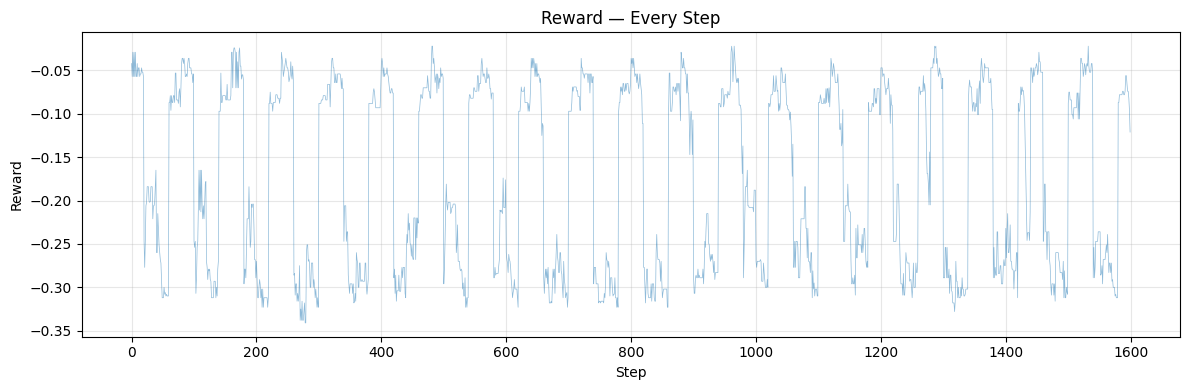

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["reward"], alpha=0.5, linewidth=0.5)
ax.set_xlabel("Step"); ax.set_ylabel("Reward")
ax.set_title("Reward — Every Step")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Chart 2 data — Loss over all steps
loss_clean = df["loss"].dropna()
print(f"Loss rows with data: {len(loss_clean)} / {len(df)}")

Loss rows with data: 1569 / 1600


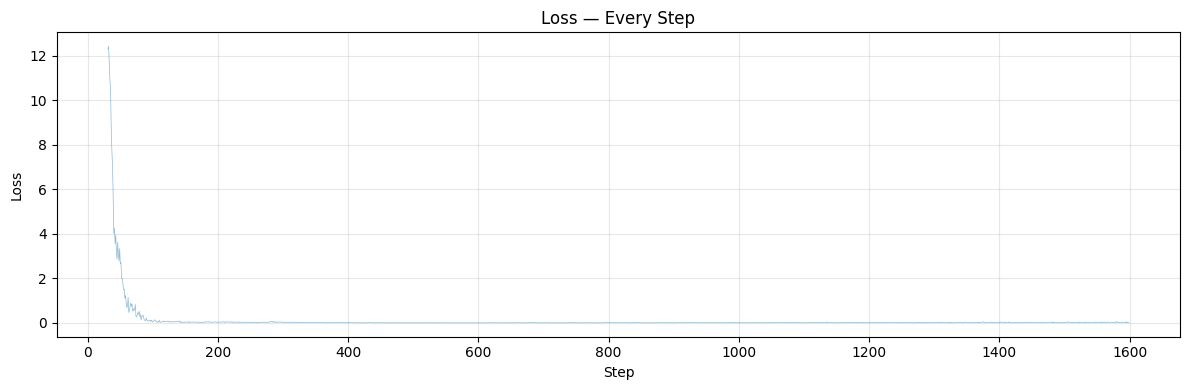

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
if len(loss_clean):
    ax.plot(loss_clean.index, loss_clean.values, alpha=0.5, linewidth=0.5)
    ax.set_xlabel("Step"); ax.set_ylabel("Loss")
    ax.set_title("Loss — Every Step")
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "No loss data", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout()
plt.show()

In [9]:
# Chart 3 data — Average reward per iteration
if df_summary is not None and "avg_reward" in df_summary.columns:
    iter_ids = df_summary["iteration"]
    avg_rew = df_summary["avg_reward"]
    src = "summary.json"
else:
    iter_ids = df.groupby("iteration")["reward"].mean().index
    avg_rew = df.groupby("iteration")["reward"].mean().values
    src = "raw metrics"
print(f"Source: {src}, iterations: {len(iter_ids)}")

Source: summary.json, iterations: 20


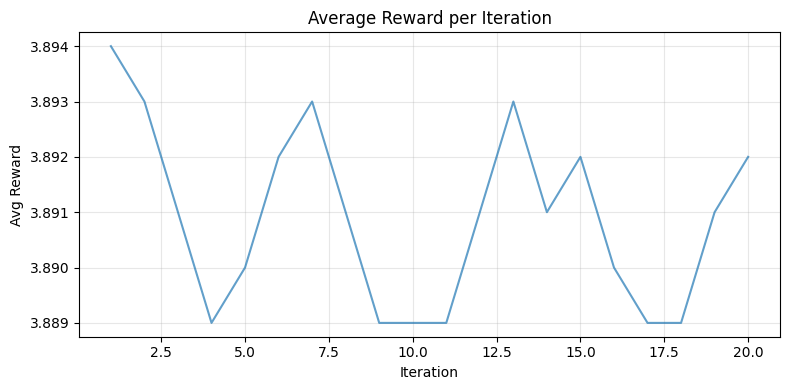

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(iter_ids, avg_rew, alpha=0.7)
ax.set_xlabel("Iteration"); ax.set_ylabel("Avg Reward")
ax.set_title("Average Reward per Iteration")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Chart 4 data — Average loss per iteration
if df_summary is not None and "avg_loss" in df_summary.columns:
    _loss_vals = df_summary["avg_loss"].dropna()
    if len(_loss_vals):
        iter_loss_ids = df_summary.loc[_loss_vals.index, "iteration"]
        avg_loss_vals = _loss_vals.values
        src = "summary.json"
    else:
        iter_loss_ids = None
        src = "none"
else:
    grp = df.groupby("iteration")["loss"].mean().dropna()
    if len(grp):
        iter_loss_ids = grp.index
        avg_loss_vals = grp.values
        src = "raw metrics"
    else:
        iter_loss_ids = None
        src = "none"
print(f"Source: {src}, iterations with loss: {len(avg_loss_vals) if iter_loss_ids is not None else 0}")

Source: summary.json, iterations with loss: 20


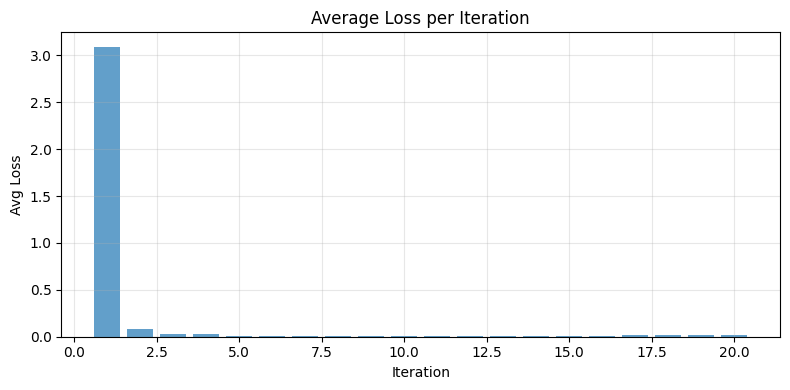

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
if iter_loss_ids is not None and len(iter_loss_ids):
    ax.bar(iter_loss_ids, avg_loss_vals, alpha=0.7)
    ax.set_xlabel("Iteration"); ax.set_ylabel("Avg Loss")
    ax.set_title("Average Loss per Iteration")
    ax.grid(True, alpha=0.3)
else:
    ax.text(0.5, 0.5, "No loss data", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout()
plt.show()

In [13]:
# Chart 5 data — Epsilon decay
if df_summary is not None and "epsilon" in df_summary.columns:
    eps_iters = df_summary["iteration"]
    eps_vals = df_summary["epsilon"]
    src = "summary.json"
else:
    grp = df.groupby("iteration")["epsilon"].first()
    eps_iters = grp.index
    eps_vals = grp.values
    src = "raw metrics"
print(f"Source: {src}, iterations: {len(eps_iters)}")

Source: summary.json, iterations: 20


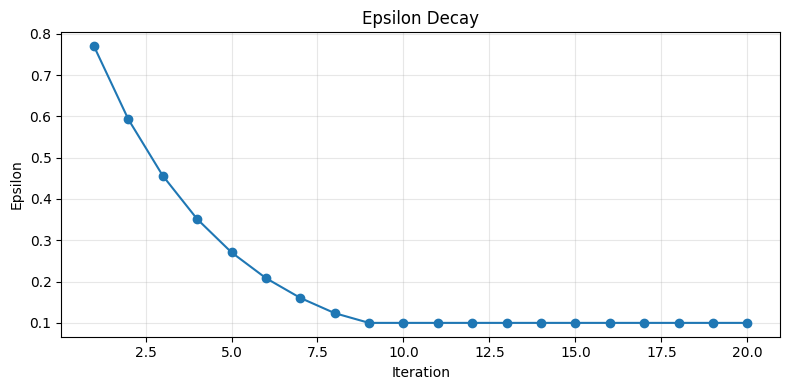

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eps_iters, eps_vals, "o-")
ax.set_xlabel("Iteration"); ax.set_ylabel("Epsilon")
ax.set_title("Epsilon Decay")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Chart 6 data — Parameter values over all steps
print(f"Parameter columns: {param_cols}")

Parameter columns: ['speedFactor', 'improvement']


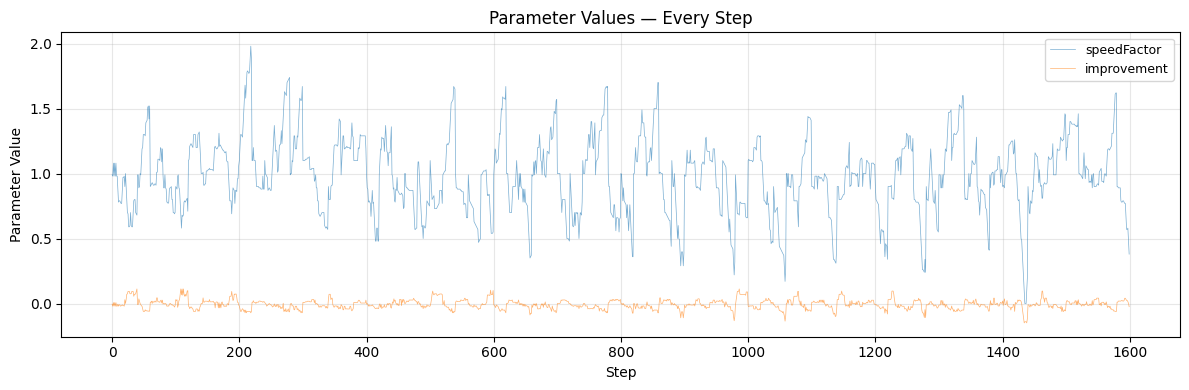

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
if param_cols:
    for col in param_cols:
        ax.plot(df.index, df[col], alpha=0.6, linewidth=0.5, label=col)
    ax.set_xlabel("Step"); ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Values — Every Step")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No parameter columns", ha="center", va="center", transform=ax.transAxes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Chart 7 data — Total and avg reward per data point across iterations
SELECTED_INDICES = [3, 4, 7, 5, 6]  # <-- edit

subset = df[df["data_point"].isin(SELECTED_INDICES)].copy()
available = sorted(df["data_point"].unique())
print(f"Selected: {SELECTED_INDICES}")
print(f"Available data points: {available}")

if not subset.empty:
    grp = subset.groupby(["iteration", "data_point"])["reward"].agg(["sum", "mean"]).reset_index()
    print(f"Grouped into {len(grp)} (iteration, data_point) rows")
    display(grp)
else:
    grp = None
    print("WARNING: No data found for selected indices.")

Selected: [3, 4, 7, 5, 6]
Available data points: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Grouped into 20 (iteration, data_point) rows


,iteration,data_point,sum,mean
0,1,3,-1.602,-0.08010
1,2,3,-1.646,-0.08230
2,3,3,-1.692,-0.08460
3,4,3,-1.598,-0.07990
4,5,3,-1.736,-0.08680
5,6,3,-1.524,-0.07620
6,7,3,-1.471,-0.07355
7,8,3,-1.685,-0.08425
8,9,3,-1.639,-0.08195
9,10,3,-1.462,-0.07310


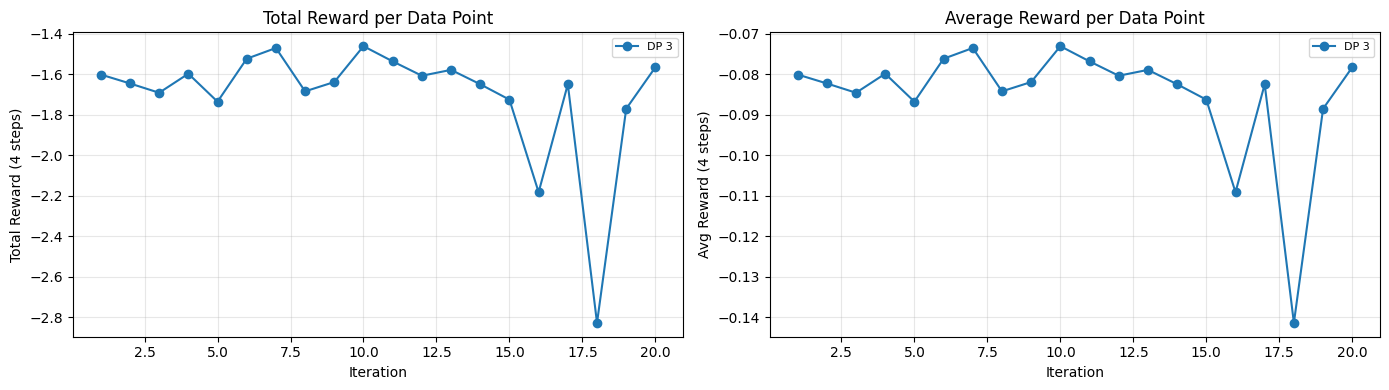

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

if grp is not None and not grp.empty:
    for dp_id in SELECTED_INDICES:
        dp_grp = grp[grp["data_point"] == dp_id].sort_values("iteration")
        if dp_grp.empty:
            continue
        ax1.plot(dp_grp["iteration"], dp_grp["sum"], "o-", label=f"DP {dp_id}")
        ax2.plot(dp_grp["iteration"], dp_grp["mean"], "o-", label=f"DP {dp_id}")
    ax1.set_xlabel("Iteration"); ax1.set_ylabel("Total Reward (4 steps)")
    ax1.set_title("Total Reward per Data Point"); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
    ax2.set_xlabel("Iteration"); ax2.set_ylabel("Avg Reward (4 steps)")
    ax2.set_title("Average Reward per Data Point"); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax1.transAxes)
    ax2.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax2.transAxes)
plt.tight_layout()
plt.show()

In [19]:
# Chart 8 data — Sim vs Expected (same SELECTED_INDICES as above)
SELECTED_INDICES_V2 = [0, 1, 2, 5, 6]  # <-- edit

subset_v2 = df[df["data_point"].isin(SELECTED_INDICES_V2)].copy()
print(f"Selected: {SELECTED_INDICES_V2}")
print(f"Rows: {len(subset_v2)}")

Selected: [0, 1, 2, 5, 6]
Rows: 1200


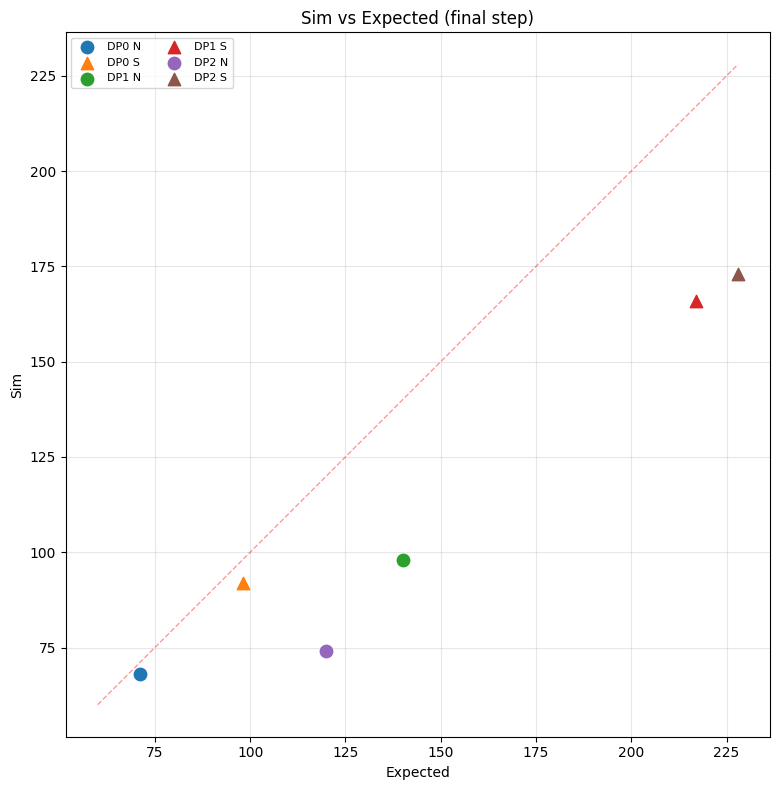

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))
if not subset_v2.empty:
    for dp_id in SELECTED_INDICES_V2:
        dp_data = subset_v2[subset_v2["data_point"] == dp_id]
        if dp_data.empty:
            continue
        last_step = dp_data["step_in_data"].max()
        last = dp_data[dp_data["step_in_data"] == last_step]
        if last.empty:
            last = dp_data
        row = last.iloc[-1]
        ax.scatter(row["expected_north"], row["sim_north"],
                   marker="o", s=80, label=f"DP{dp_id} N", zorder=5)
        ax.scatter(row["expected_south"], row["sim_south"],
                   marker="^", s=80, label=f"DP{dp_id} S", zorder=5)

    all_exp = pd.concat([subset_v2["expected_north"], subset_v2["expected_south"]])
    all_sim = pd.concat([subset_v2["sim_north"], subset_v2["sim_south"]])
    if len(all_exp) > 0:
        lo = min(all_exp.min(), all_sim.min())
        hi = max(all_exp.max(), all_sim.max())
        ax.plot([lo, hi], [lo, hi], "r--", alpha=0.4, linewidth=1)
    ax.set_xlabel("Expected"); ax.set_ylabel("Sim")
    ax.set_title("Sim vs Expected (final step)")
    ax.legend(fontsize=8, ncol=2)
    ax.set_aspect("equal")
else:
    ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# Chart 9 data — Parameter tuning by data point
SELECTED_INDICES_V3 = [0, 1, 2, 5]  # <-- edit

subset_v3 = df[df["data_point"].isin(SELECTED_INDICES_V3)].copy()
print(f"Selected: {SELECTED_INDICES_V3}")
print(f"Rows: {len(subset_v3)}")
print(f"Parameter columns: {param_cols}")

Selected: [0, 1, 2, 5]
Rows: 1200
Parameter columns: ['speedFactor', 'improvement']


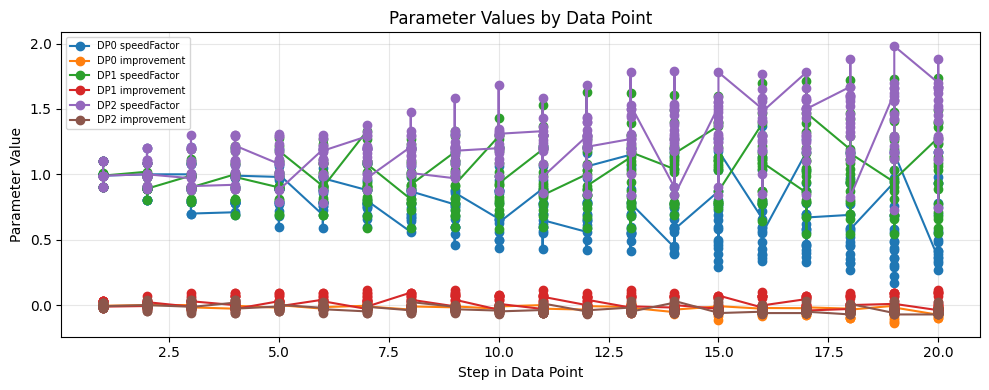

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
if not subset_v3.empty and param_cols:
    for dp_id in SELECTED_INDICES_V3:
        dp_data = subset_v3[subset_v3["data_point"] == dp_id].sort_values("step_in_data")
        if dp_data.empty:
            continue
        for pc in param_cols:
            ax.plot(dp_data["step_in_data"], dp_data[pc],
                    "o-", label=f"DP{dp_id} {pc}")
    ax.set_xlabel("Step in Data Point"); ax.set_ylabel("Parameter Value")
    ax.set_title("Parameter Values by Data Point")
    ax.legend(fontsize=7)
elif not param_cols:
    ax.text(0.5, 0.5, "No parameter columns", ha="center", va="center", transform=ax.transAxes)
else:
    ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
if not subset_v3.empty:
    last_steps = subset_v3[subset_v3["step_in_data"] == subset_v3["step_in_data"].max()]
    print("Final-step values for selected data points:")
    display(last_steps.reset_index(drop=True))
else:
    print("No data to display.")

Final-step values for selected data points:


,iteration,data_point,step_in_data,reward,sim_south,sim_north,expected_south,expected_north,error_south,error_north,speedFactor,epsilon,loss,improvement
0,1,0,20,-0.057,91,68,98,71,-7.0,-3.0,0.98,1.0000,NaN,-0.020408
1,1,1,20,-0.165,175,121,217,140,-42.0,-19.0,0.68,1.0000,5.691812,0.112327
2,1,2,20,-0.310,174,74,228,120,-54.0,-46.0,1.52,1.0000,0.896746,-0.058772
3,2,0,20,-0.054,93,67,98,71,-5.0,-4.0,0.70,0.7700,0.076302,-0.017246
4,2,1,20,-0.178,174,118,217,140,-43.0,-22.0,0.71,0.7700,0.067641,0.099309
5,2,2,20,-0.270,177,82,228,120,-51.0,-38.0,1.12,0.7700,0.059369,-0.018860
6,3,0,20,-0.060,89,69,98,71,-9.0,-2.0,1.17,0.5929,0.023501,-0.023570
7,3,1,20,-0.289,163,94,217,140,-54.0,-46.0,1.06,0.5929,0.024732,-0.011751
8,3,2,20,-0.312,173,74,228,120,-55.0,-46.0,1.88,0.5929,0.021294,-0.060965
9,4,0,20,-0.060,89,69,98,71,-9.0,-2.0,1.17,0.4565,0.009272,-0.023570
